# FULL PIPELINE SUBSTANCES CLASSIFICATION (PART 1) - data preparation:

Metals included

## 1. Molecular descriptors calculation (RDKit):

#### 1. Set-up:

In [31]:
## packages to install if required (remove hashtag and run):
#!pip install pysmiles
#!pip install descriptastorus
#!pip install rdkit

In [32]:
## import necessary libraries:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from pysmiles import read_smiles

from descriptastorus.descriptors.DescriptorGenerator import MakeGenerator

from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem, PandasTools
from rdkit.ML.Descriptors import MoleculeDescriptors

In [33]:
## export dataframe with substances + SMILES:
smiles_df = pd.read_csv('../data/contaminants_detected.csv', delimiter = ";")
smiles_df

,name,substance_type,CAS_nb,SMILES,detected,typol_class_tab_2
0,carbaryl,insecticide,63-25-2,CNC(=O)OC1=CC=CC2=CC=CC=C21,1.0,1.0
1,chlorpyrifos,insecticide,2921-88-2,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,1.0,3.0
2,cypermethrine,insecticide,52315-07-8,CC1(C(C1C(=O)OC(C#N)C2=CC(=CC=C2)OC3=CC=CC=C3)...,1.0,4.0
3,DDD(2-4),insecticide,72-54-8,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)Cl)Cl,1.0,3.0
4,dicofol,insecticide,115-32-2,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)(C(Cl)(Cl)Cl)O)Cl,1.0,NaN
...,...,...,...,...,...,...
70,NaN,NaN,NaN,NaN,NaN,NaN
71,NaN,NaN,NaN,NaN,NaN,NaN
72,NaN,NaN,NaN,NaN,NaN,NaN
73,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
## data cleaning:
print(f"Length of database with NAs: {len(smiles_df.SMILES)}")

if smiles_df.SMILES.isna().sum() > 0:
    smiles_cleaned = smiles_df.loc[smiles_df.SMILES.notna()].copy() ## remove NAs (cannot compute molecular descriptor if no SMILES structure present)
    print(f"Length of database without NAs (cleaned version): {len(smiles_cleaned.SMILES)}")
else:
    None

smiles_cleaned = smiles_cleaned.drop("CAS_nb", axis = 1).copy()

Length of database with NAs: 75
Length of database without NAs (cleaned version): 43


In [35]:
smiles_cleaned

,name,substance_type,SMILES,detected,typol_class_tab_2
0,carbaryl,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21,1.0,1.0
1,chlorpyrifos,insecticide,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,1.0,3.0
2,cypermethrine,insecticide,CC1(C(C1C(=O)OC(C#N)C2=CC(=CC=C2)OC3=CC=CC=C3)...,1.0,4.0
3,DDD(2-4),insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)Cl)Cl,1.0,3.0
4,dicofol,insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)(C(Cl)(Cl)Cl)O)Cl,1.0,NaN
5,dieldrin,insecticide,C1[C@@H]2[C@H]3[C@@H]([C@H]1[C@H]4[C@@H]2O4)[C...,1.0,2.0
6,isodrin,insecticide,C1[C@@H]2C=C[C@H]1[C@@H]3[C@H]2[C@@]4(C(=C([C@...,1.0,2.0
7,lindane,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21.C1(C(C(C(C(C1Cl)Cl...,1.0,1.0
8,methomyl,insecticide,CC(=NOC(=O)NC)SC,1.0,NaN
9,tebufenozide,insecticide,CCC1=CC=C(C=C1)C(=O)NN(C(=O)C2=CC(=CC(=C2)C)C)...,1.0,NaN


In [36]:
## extract list of molecules from their SMILES:
smiles_list = smiles_cleaned.SMILES

mol_list = []

for s in smiles_list:
    mol = Chem.MolFromSmiles(s)
    mol_list.append(mol)

,name,substance_type,SMILES,detected,typol_class_tab_2,molecule
0,carbaryl,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21,1.0,1.0,
1,chlorpyrifos,insecticide,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,1.0,3.0,
2,cypermethrine,insecticide,CC1(C(C1C(=O)OC(C#N)C2=CC(=CC=C2)OC3=CC=CC=C3)...,1.0,4.0,
3,DDD(2-4),insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)Cl)Cl,1.0,3.0,
4,dicofol,insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)(C(Cl)(Cl)Cl)O)Cl,1.0,NaN,
5,dieldrin,insecticide,C1[C@@H]2[C@H]3[C@@H]([C@H]1[C@H]4[C@@H]2O4)[C...,1.0,2.0,
6,isodrin,insecticide,C1[C@@H]2C=C[C@H]1[C@@H]3[C@H]2[C@@]4(C(=C([C@...,1.0,2.0,
7,lindane,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21.C1(C(C(C(C(C1Cl)Cl...,1.0,1.0,
8,methomyl,insecticide,CC(=NOC(=O)NC)SC,1.0,NaN,
9,tebufenozide,insecticide,CCC1=CC=C(C=C1)C(=O)NN(C(=O)C2=CC(=CC(=C2)C)C)...,1.0,NaN,

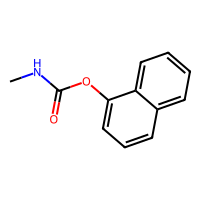
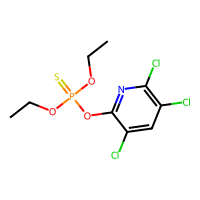
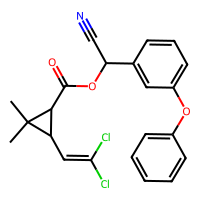
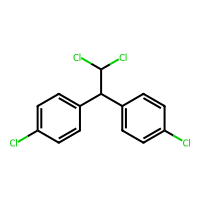
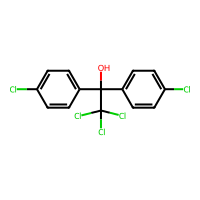
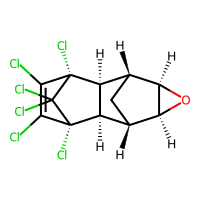
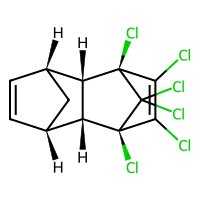
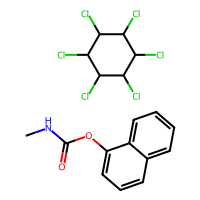
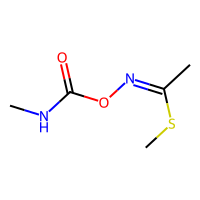
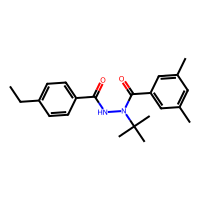
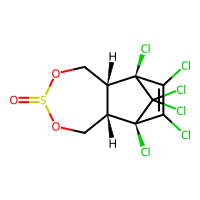
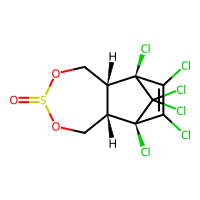
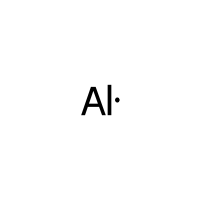
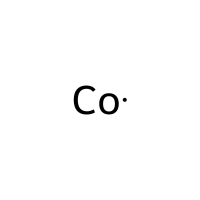
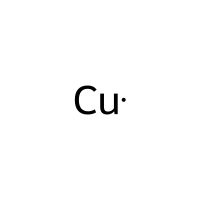
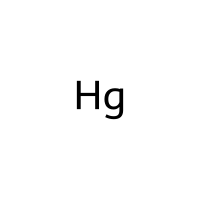
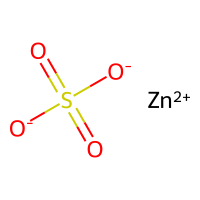
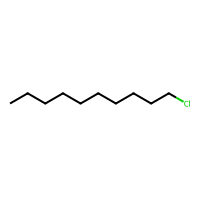
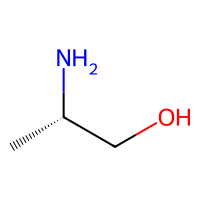
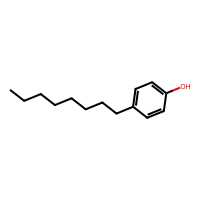
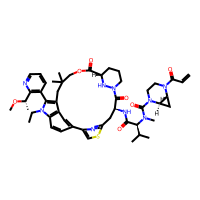
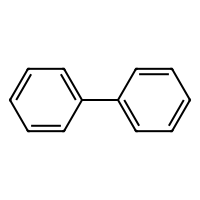
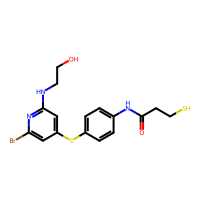
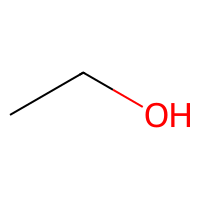
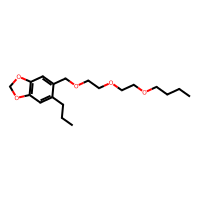
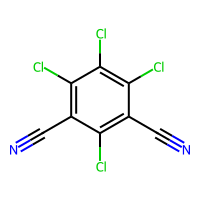
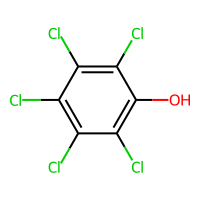
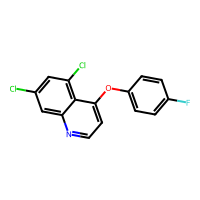
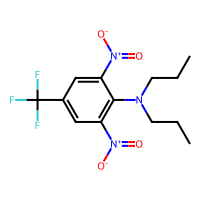
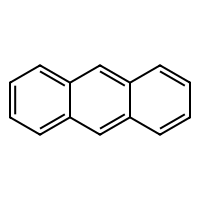
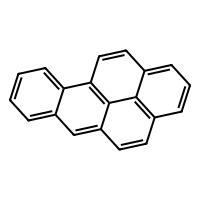
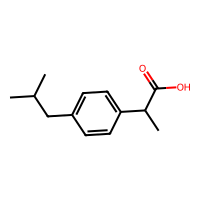
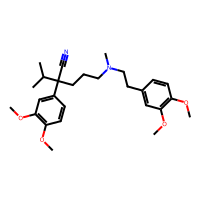
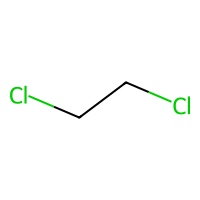
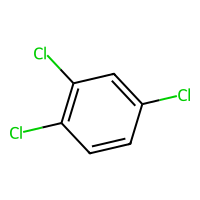
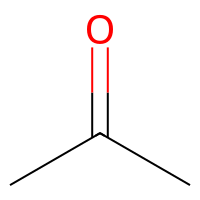
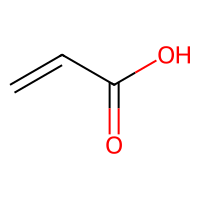
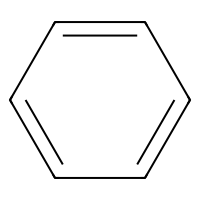
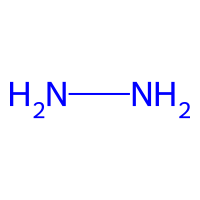
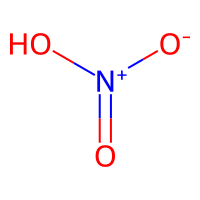
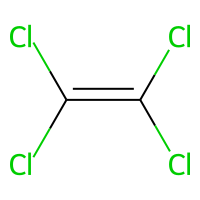
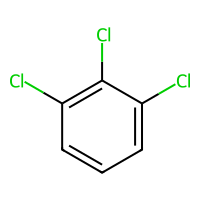
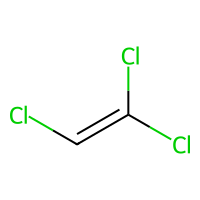

In [37]:
## add molecule column to df:
PandasTools.AddMoleculeColumnToFrame(smiles_cleaned, "SMILES", "molecule", includeFingerprints = True)
smiles_cleaned.molecule = mol_list
smiles_cleaned

#### 2. Basic chemical analysis of database:

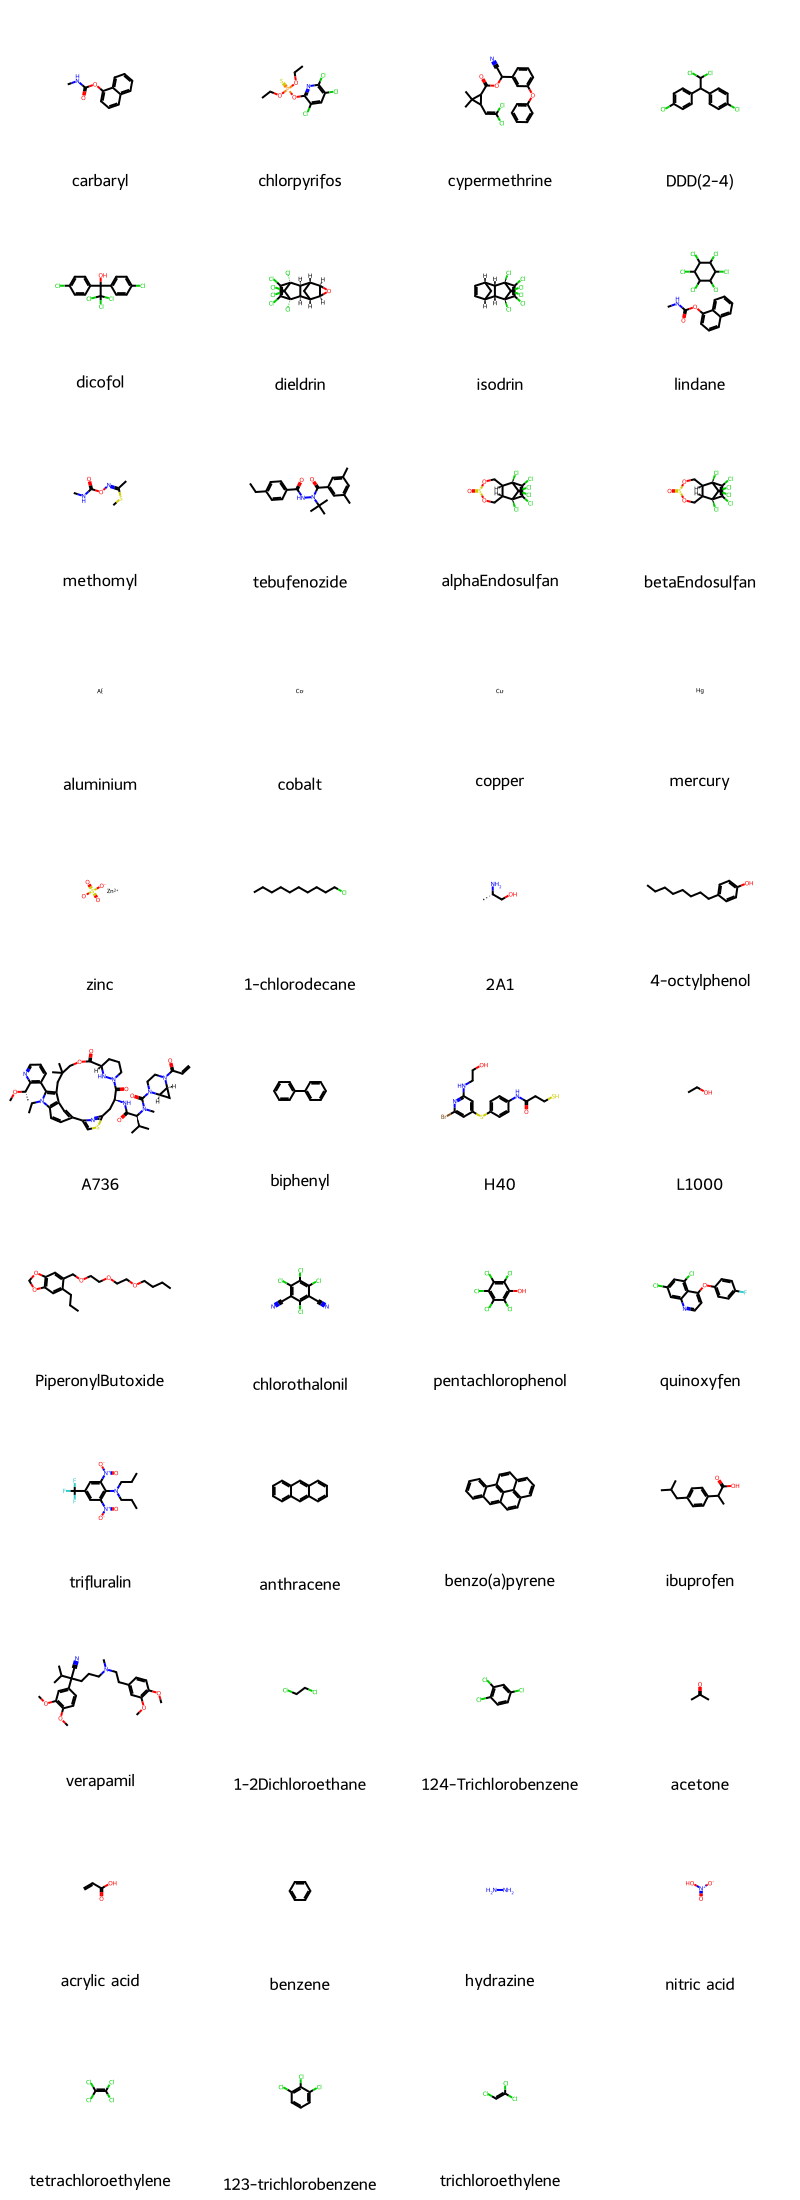

In [38]:
## visualise 2D rep of substances from their SMILES (just to see, for fun):
pic = Draw.MolsToGridImage(mol_list, molsPerRow = 4, maxMols = 70, subImgSize = (200, 200), legends = list(smiles_cleaned.name), returnPNG = False)
pic

In [39]:
## save molecular visualisation of present substances:
pic.save("../plots/2d_rep_mols.png") ## make a file called "plots" (or another name, but change it) to save image in

#### 3. Calculation of molecular descriptors:

In [40]:
Desc_list_func = MoleculeDescriptors.MolecularDescriptorCalculator(x[0] for x in Descriptors._descList)
names = Desc_list_func.GetDescriptorNames()

In [41]:
des = []

for mol in smiles_cleaned["molecule"]:
  des.append(Desc_list_func.CalcDescriptors(mol))

rdkit_df = pd.concat([smiles_cleaned.reset_index(drop = True), pd.DataFrame(des).reset_index(drop = True)], axis = 1)
rdkit_df

,name,substance_type,SMILES,detected,typol_class_tab_2,molecule,0,1,2,3,...,207,208,209,210,211,212,213,214,215,216
0,carbaryl,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21,1.0,1.0,<rdkit.Chem.rdchem.Mol object at 0x177188900>,11.091562,11.091562,0.452451,-0.452451,...,0,0,0,0,0,0,0,0,0,0
1,chlorpyrifos,insecticide,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,1.0,3.0,<rdkit.Chem.rdchem.Mol object at 0x17718a570>,5.937656,5.937656,0.052130,-2.918479,...,0,0,0,0,0,0,0,0,0,0
2,cypermethrine,insecticide,CC1(C(C1C(=O)OC(C#N)C2=CC(=CC=C2)OC3=CC=CC=C3)...,1.0,4.0,<rdkit.Chem.rdchem.Mol object at 0x17718a490>,12.611418,12.611418,0.113804,-1.028401,...,0,0,0,0,0,0,0,0,0,0
3,DDD(2-4),insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)Cl)Cl,1.0,3.0,<rdkit.Chem.rdchem.Mol object at 0x1771897e0>,6.091872,6.091872,0.094568,-0.534860,...,0,0,0,0,0,0,0,0,0,0
4,dicofol,insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)(C(Cl)(Cl)Cl)O)Cl,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x177189700>,10.990246,10.990246,0.420576,-1.963632,...,0,0,0,0,0,0,0,0,0,0
5,dieldrin,insecticide,C1[C@@H]2[C@H]3[C@@H]([C@H]1[C@H]4[C@@H]2O4)[C...,1.0,2.0,<rdkit.Chem.rdchem.Mol object at 0x17718b220>,6.824159,6.824159,0.046682,-1.374691,...,0,0,0,0,0,0,0,0,0,0
6,isodrin,insecticide,C1[C@@H]2C=C[C@H]1[C@@H]3[C@H]2[C@@]4(C(=C([C@...,1.0,2.0,<rdkit.Chem.rdchem.Mol object at 0x177189ee0>,6.761998,6.761998,0.066358,-1.365525,...,0,0,0,0,0,0,0,0,0,0
7,lindane,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21.C1(C(C(C(C(C1Cl)Cl...,1.0,1.0,<rdkit.Chem.rdchem.Mol object at 0x177188b30>,11.091562,11.091562,0.436728,-0.452451,...,0,0,0,0,0,0,0,0,0,0
8,methomyl,insecticide,CC(=NOC(=O)NC)SC,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x17718b3e0>,10.382504,10.382504,0.547778,-0.547778,...,1,0,0,0,0,0,0,0,0,0
9,tebufenozide,insecticide,CCC1=CC=C(C=C1)C(=O)NN(C(=O)C2=CC(=CC(=C2)C)C)...,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x17718b920>,13.074419,13.074419,0.219603,-0.561752,...,0,0,0,0,0,0,0,0,0,0


#### 4. Cleaning of MD db (check NAs, replace NAs, etc):

In [42]:
condition = rdkit_df.iloc[:, 6:223].isna().sum() ## set condition on NA nb threshold

nas_replace = condition[(condition > 0) & (condition <= 10)].index ## indexes of cols where there is less than 10 NAs

rdkit_df[nas_replace] = rdkit_df[nas_replace].fillna(0) ## replace NA values with 0
rdkit_df ## check db & how it looks like now

,name,substance_type,SMILES,detected,typol_class_tab_2,molecule,0,1,2,3,...,207,208,209,210,211,212,213,214,215,216
0,carbaryl,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21,1.0,1.0,<rdkit.Chem.rdchem.Mol object at 0x177188900>,11.091562,11.091562,0.452451,-0.452451,...,0,0,0,0,0,0,0,0,0,0
1,chlorpyrifos,insecticide,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,1.0,3.0,<rdkit.Chem.rdchem.Mol object at 0x17718a570>,5.937656,5.937656,0.052130,-2.918479,...,0,0,0,0,0,0,0,0,0,0
2,cypermethrine,insecticide,CC1(C(C1C(=O)OC(C#N)C2=CC(=CC=C2)OC3=CC=CC=C3)...,1.0,4.0,<rdkit.Chem.rdchem.Mol object at 0x17718a490>,12.611418,12.611418,0.113804,-1.028401,...,0,0,0,0,0,0,0,0,0,0
3,DDD(2-4),insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)Cl)Cl,1.0,3.0,<rdkit.Chem.rdchem.Mol object at 0x1771897e0>,6.091872,6.091872,0.094568,-0.534860,...,0,0,0,0,0,0,0,0,0,0
4,dicofol,insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)(C(Cl)(Cl)Cl)O)Cl,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x177189700>,10.990246,10.990246,0.420576,-1.963632,...,0,0,0,0,0,0,0,0,0,0
5,dieldrin,insecticide,C1[C@@H]2[C@H]3[C@@H]([C@H]1[C@H]4[C@@H]2O4)[C...,1.0,2.0,<rdkit.Chem.rdchem.Mol object at 0x17718b220>,6.824159,6.824159,0.046682,-1.374691,...,0,0,0,0,0,0,0,0,0,0
6,isodrin,insecticide,C1[C@@H]2C=C[C@H]1[C@@H]3[C@H]2[C@@]4(C(=C([C@...,1.0,2.0,<rdkit.Chem.rdchem.Mol object at 0x177189ee0>,6.761998,6.761998,0.066358,-1.365525,...,0,0,0,0,0,0,0,0,0,0
7,lindane,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21.C1(C(C(C(C(C1Cl)Cl...,1.0,1.0,<rdkit.Chem.rdchem.Mol object at 0x177188b30>,11.091562,11.091562,0.436728,-0.452451,...,0,0,0,0,0,0,0,0,0,0
8,methomyl,insecticide,CC(=NOC(=O)NC)SC,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x17718b3e0>,10.382504,10.382504,0.547778,-0.547778,...,1,0,0,0,0,0,0,0,0,0
9,tebufenozide,insecticide,CCC1=CC=C(C=C1)C(=O)NN(C(=O)C2=CC(=CC(=C2)C)C)...,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x17718b920>,13.074419,13.074419,0.219603,-0.561752,...,0,0,0,0,0,0,0,0,0,0


In [43]:
## check if there's still NAs present or not
rdkit_df.all().isna().sum() ## 0

0

#### 5. Export results to .csv file:

In [44]:
rdkit_df.to_csv("../data/rdkit_descriptors_met.csv", index = False)

## 2. Preparation molecular descriptors database

* Data preprocessing on Mordred and RDKit databases to then perform clustering on them
* Removal/Replacement of NAs (if any present)
* Variance threshold (set a min variance to not take into account $\Rightarrow$ little info if $\mathbb{V}[X_i] \rightarrow 0$ (with $X_i$ a molecular descriptor and $i = 1, ..., N$, $N$ the number of molecular descriptors))
* Correlation plot (heatmap with the package seaborn): remove highly correlated molecular descriptors (to avoid columns that resemble each other and therefore remove any noise in the db so that it is ready to run models on it, whether it is a stat/ML/DL model)


#### 0. Initialise

In [45]:
## libraries to import
from scipy import stats

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from cmcrameri import cm
import seaborn as sns
%matplotlib inline

In [46]:
sns.set(style = 'white', context = 'notebook', rc = {'figure.figsize':(14, 10)})

#### 1. Import db:

In [47]:
data2 = pd.read_csv("../data/rdkit_descriptors_met.csv", delimiter = ",")
data2

,name,substance_type,SMILES,detected,typol_class_tab_2,molecule,0,1,2,3,...,207,208,209,210,211,212,213,214,215,216
0,carbaryl,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21,1.0,1.0,<rdkit.Chem.rdchem.Mol object at 0x177188900>,11.091562,11.091562,0.452451,-0.452451,...,0,0,0,0,0,0,0,0,0,0
1,chlorpyrifos,insecticide,CCOP(=S)(OCC)OC1=NC(=C(C=C1Cl)Cl)Cl,1.0,3.0,<rdkit.Chem.rdchem.Mol object at 0x17718a570>,5.937656,5.937656,0.052130,-2.918479,...,0,0,0,0,0,0,0,0,0,0
2,cypermethrine,insecticide,CC1(C(C1C(=O)OC(C#N)C2=CC(=CC=C2)OC3=CC=CC=C3)...,1.0,4.0,<rdkit.Chem.rdchem.Mol object at 0x17718a490>,12.611418,12.611418,0.113804,-1.028401,...,0,0,0,0,0,0,0,0,0,0
3,DDD(2-4),insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)Cl)Cl,1.0,3.0,<rdkit.Chem.rdchem.Mol object at 0x1771897e0>,6.091872,6.091872,0.094568,-0.534860,...,0,0,0,0,0,0,0,0,0,0
4,dicofol,insecticide,C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)(C(Cl)(Cl)Cl)O)Cl,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x177189700>,10.990246,10.990246,0.420576,-1.963632,...,0,0,0,0,0,0,0,0,0,0
5,dieldrin,insecticide,C1[C@@H]2[C@H]3[C@@H]([C@H]1[C@H]4[C@@H]2O4)[C...,1.0,2.0,<rdkit.Chem.rdchem.Mol object at 0x17718b220>,6.824159,6.824159,0.046682,-1.374691,...,0,0,0,0,0,0,0,0,0,0
6,isodrin,insecticide,C1[C@@H]2C=C[C@H]1[C@@H]3[C@H]2[C@@]4(C(=C([C@...,1.0,2.0,<rdkit.Chem.rdchem.Mol object at 0x177189ee0>,6.761998,6.761998,0.066358,-1.365525,...,0,0,0,0,0,0,0,0,0,0
7,lindane,insecticide,CNC(=O)OC1=CC=CC2=CC=CC=C21.C1(C(C(C(C(C1Cl)Cl...,1.0,1.0,<rdkit.Chem.rdchem.Mol object at 0x177188b30>,11.091562,11.091562,0.436728,-0.452451,...,0,0,0,0,0,0,0,0,0,0
8,methomyl,insecticide,CC(=NOC(=O)NC)SC,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x17718b3e0>,10.382504,10.382504,0.547778,-0.547778,...,1,0,0,0,0,0,0,0,0,0
9,tebufenozide,insecticide,CCC1=CC=C(C=C1)C(=O)NN(C(=O)C2=CC(=CC(=C2)C)C)...,1.0,NaN,<rdkit.Chem.rdchem.Mol object at 0x17718b920>,13.074419,13.074419,0.219603,-0.561752,...,0,0,0,0,0,0,0,0,0,0


In [48]:
## get only mol. descr.:
rdkit_md = data2.drop({"name", "substance_type", "SMILES", "detected", "molecule", "typol_class_tab_2"}, axis = 1)
rdkit_md

,0,1,2,3,4,5,6,7,8,9,...,207,208,209,210,211,212,213,214,215,216
0,11.091562,11.091562,0.452451,-0.452451,0.769567,9.933333,201.225,190.137,201.078979,76,...,0,0,0,0,0,0,0,0,0,0
1,5.937656,5.937656,0.052130,-2.918479,0.548341,11.611111,350.591,339.503,348.926284,102,...,0,0,0,0,0,0,0,0,0,0
2,12.611418,12.611418,0.113804,-1.028401,0.528047,20.392857,416.304,397.152,415.074199,144,...,0,0,0,0,0,0,0,0,0,0
3,6.091872,6.091872,0.094568,-0.534860,0.615021,11.222222,320.046,309.966,317.953661,94,...,0,0,0,0,0,0,0,0,0,0
4,10.990246,10.990246,0.420576,-1.963632,0.682416,12.500000,370.490,361.418,367.909603,106,...,0,0,0,0,0,0,0,0,0,0
5,6.824159,6.824159,0.046682,-1.374691,0.342678,66.631579,380.913,372.849,377.870631,104,...,0,0,0,0,0,0,0,0,0,0
6,6.761998,6.761998,0.066358,-1.365525,0.311830,58.777778,364.914,356.850,361.875716,98,...,0,0,0,0,0,0,0,0,0,0
7,11.091562,11.091562,0.436728,-0.452451,0.481974,30.185185,492.057,474.921,488.939045,148,...,0,0,0,0,0,0,0,0,0,0
8,10.382504,10.382504,0.547778,-0.547778,0.271082,10.900000,162.214,152.134,162.046299,58,...,1,0,0,0,0,0,0,0,0,0
9,13.074419,13.074419,0.219603,-0.561752,0.829715,11.153846,352.478,324.254,352.215078,138,...,0,0,0,0,0,0,0,0,0,0


#### 2 - NAs:

In [49]:
## check if any NAs before:
print(f"Number of NAs in RDKit database: \n {rdkit_md.isna().sum().sum()}")

Number of NAs in RDKit database: 
 0


In [50]:
rdkit_clean = rdkit_md.fillna(0)
rdkit_clean.head(4)

,0,1,2,3,4,5,6,7,8,9,...,207,208,209,210,211,212,213,214,215,216
0,11.091562,11.091562,0.452451,-0.452451,0.769567,9.933333,201.225,190.137,201.078979,76,...,0,0,0,0,0,0,0,0,0,0
1,5.937656,5.937656,0.052130,-2.918479,0.548341,11.611111,350.591,339.503,348.926284,102,...,0,0,0,0,0,0,0,0,0,0
2,12.611418,12.611418,0.113804,-1.028401,0.528047,20.392857,416.304,397.152,415.074199,144,...,0,0,0,0,0,0,0,0,0,0
3,6.091872,6.091872,0.094568,-0.534860,0.615021,11.222222,320.046,309.966,317.953661,94,...,0,0,0,0,0,0,0,0,0,0


In [51]:
## check if inf values in data:
print(f"Number of infinite values in RDKit database: {np.isinf(rdkit_clean).sum().sum()}")

Number of infinite values in RDKit database: 0


In [52]:
#stats.zscore(rdkit_clean)
rdkit_clean[np.abs(stats.zscore(rdkit_clean.iloc[:, 5])) < 3]

,0,1,2,3,4,5,6,7,8,9,...,207,208,209,210,211,212,213,214,215,216
0,11.091562,11.091562,0.452451,-0.452451,0.769567,9.933333,201.225,190.137,201.078979,76,...,0,0,0,0,0,0,0,0,0,0
1,5.937656,5.937656,0.052130,-2.918479,0.548341,11.611111,350.591,339.503,348.926284,102,...,0,0,0,0,0,0,0,0,0,0
2,12.611418,12.611418,0.113804,-1.028401,0.528047,20.392857,416.304,397.152,415.074199,144,...,0,0,0,0,0,0,0,0,0,0
3,6.091872,6.091872,0.094568,-0.534860,0.615021,11.222222,320.046,309.966,317.953661,94,...,0,0,0,0,0,0,0,0,0,0
4,10.990246,10.990246,0.420576,-1.963632,0.682416,12.500000,370.490,361.418,367.909603,106,...,0,0,0,0,0,0,0,0,0,0
6,6.761998,6.761998,0.066358,-1.365525,0.311830,58.777778,364.914,356.850,361.875716,98,...,0,0,0,0,0,0,0,0,0,0
7,11.091562,11.091562,0.436728,-0.452451,0.481974,30.185185,492.057,474.921,488.939045,148,...,0,0,0,0,0,0,0,0,0,0
8,10.382504,10.382504,0.547778,-0.547778,0.271082,10.900000,162.214,152.134,162.046299,58,...,1,0,0,0,0,0,0,0,0,0
9,13.074419,13.074419,0.219603,-0.561752,0.829715,11.153846,352.478,324.254,352.215078,138,...,0,0,0,0,0,0,0,0,0,0
10,11.316003,11.316003,0.010741,-1.860735,0.575409,52.210526,406.929,400.881,403.816881,108,...,0,0,0,0,0,0,0,0,0,0


#### 3 - Variance Threshold:

* Computes variance for each column;
* Set a threshold;
* If variance is lower than the threshold, don't select the column as the molecular descriptor contains little info and would not be useful for the analysis;
* Helps in reducing noise in database


In [53]:
selector = VarianceThreshold(threshold = 0.05)
var_reduced2 = selector.fit_transform(rdkit_clean)

In [54]:
## transform to df (so it can be used more easily afterwards):
rdkit_var = pd.DataFrame(var_reduced2, index = data2.name, columns = selector.get_feature_names_out())
rdkit_var.head(2)

,0,1,2,3,5,6,7,8,9,10,...,168,173,176,177,187,189,190,191,205,215
name,,,,,,,,,,,,,,,,,,,,,
carbaryl,11.091562,11.091562,0.452451,-0.452451,9.933333,201.225,190.137,201.078979,76.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
chlorpyrifos,5.937656,5.937656,0.052130,-2.918479,11.611111,350.591,339.503,348.926284,102.0,0.0,...,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


#### 4 - Save cleaned and filtered db in a .csv file:

In [55]:
## insert col sub_type again:
rdkit_var["substance_type"] = data2.substance_type.values
rdkit_var

,0,1,2,3,5,6,7,8,9,10,...,173,176,177,187,189,190,191,205,215,substance_type
name,,,,,,,,,,,,,,,,,,,,,
carbaryl,11.091562,11.091562,0.452451,-0.452451,9.933333,201.225,190.137,201.078979,76.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,insecticide
chlorpyrifos,5.937656,5.937656,0.052130,-2.918479,11.611111,350.591,339.503,348.926284,102.0,0.0,...,0.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,insecticide
cypermethrine,12.611418,12.611418,0.113804,-1.028401,20.392857,416.304,397.152,415.074199,144.0,0.0,...,2.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,insecticide
DDD(2-4),6.091872,6.091872,0.094568,-0.534860,11.222222,320.046,309.966,317.953661,94.0,0.0,...,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,insecticide
dicofol,10.990246,10.990246,0.420576,-1.963632,12.500000,370.490,361.418,367.909603,106.0,0.0,...,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,insecticide
dieldrin,6.824159,6.824159,0.046682,-1.374691,66.631579,380.913,372.849,377.870631,104.0,0.0,...,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,insecticide
isodrin,6.761998,6.761998,0.066358,-1.365525,58.777778,364.914,356.850,361.875716,98.0,0.0,...,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,insecticide
lindane,11.091562,11.091562,0.436728,-0.452451,30.185185,492.057,474.921,488.939045,148.0,0.0,...,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,insecticide
methomyl,10.382504,10.382504,0.547778,-0.547778,10.900000,162.214,152.134,162.046299,58.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,insecticide


In [56]:
## save cleaned & transformed db:
rdkit_var.to_csv("../data/rdkit_clean_met.csv", index = True)